# Análisis Exploratorio de Datos (EDA)
## Modelo de Riesgo Crediticio — Scotiabank Perú

**Objetivo:** Comprender la estructura del dataset, identificar problemas de calidad de datos
(missing values, outliers, distribuciones anómalas) y generar hipótesis sobre las variables
predictoras antes de construir cualquier modelo.

**Dataset:** `data_modelo.csv` | 50,001 observaciones | 15 columnas

**Variable objetivo:** `TARGET` — valor continuo entre 1,000 y 40,000 (escala de soles PEN)

---
**Estructura de este notebook:**
1. Configuración e importaciones
2. Carga y resumen general
3. Análisis de la variable TARGET
4. Calidad de datos: missing values y centinelas
5. Distribuciones de variables numéricas
6. Variable categórica X9 (Distrito geográfico)
7. Análisis de correlaciones
8. Análisis bivariado: features vs TARGET
9. Conclusiones y decisiones de preprocesamiento

## 1. Configuración e Importaciones

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Agregar raíz del proyecto al path para importar src/
sys.path.insert(0, str(Path('..').resolve()))
from src.config import RAW_DATA_FILE, NUMERIC_FEATURES, CATEGORICAL_FEATURES, SENTINEL_VALUE
from src.data.preprocessing import load_raw_data, replace_sentinels, missing_summary

warnings.filterwarnings('ignore')

# Estilo de gráficos profesional
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#E31837', '#002D72', '#00A3E0', '#6D6E71', '#C8C9C7']  # Colores Scotiabank
sns.set_palette(PALETTE)

print('Librerías cargadas correctamente')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Librerías cargadas correctamente
Pandas: 2.3.3 | NumPy: 2.4.4


## 2. Carga y Resumen General del Dataset

In [2]:
# Carga con encoding latin-1 (el CSV contiene caracteres especiales en nombres de distritos)
df = load_raw_data(RAW_DATA_FILE)

print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'\nColumnas: {df.columns.tolist()}')

Dimensiones: 50,001 filas × 15 columnas
Memoria: 10.4 MB

Columnas: ['ID', 'TARGET', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'BASE']


In [3]:
# Vista de los primeros registros y tipos de datos
display(df.head(5))
print('\n--- Tipos de datos ---')
display(df.dtypes.to_frame('dtype').T)

,ID,TARGET,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,BASE
0,6290921,7666,344499.0,1124.0,2509,-9999998,NaN,3.0,811.0,3,SURQUILLO,18300,95.0,27.0,TRAIN
1,621369,6062,98183.0,2664.0,2847,387252,181615.0,2.0,776.0,2,LA VICTORIA,272883,115.0,56.0,TRAIN
2,218437,6977,505263.0,4790.0,10308,6056,1886.0,4.0,643.0,2,MOYOBAMBA,181967,94.0,48.0,TRAIN
3,3089628,4122,207137.0,6427.0,1974,-9999998,NaN,1.0,633.0,1,TARAPOTO,30170,146.0,47.0,TRAIN
4,2351873,7742,154331.0,803.0,7630,6991,3222.0,1.0,854.0,1,SAN MARTIN DE PORRES,29045,40.0,33.0,TRAIN



--- Tipos de datos ---


,ID,TARGET,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,BASE
dtype,int64,int64,float64,float64,int64,int64,float64,float64,float64,int64,object,int64,float64,float64,object


In [4]:
# Distribución TRAIN / TEST
split_counts = df['BASE'].value_counts()
split_pct = (split_counts / len(df) * 100).round(1)

print('=== Distribución del dataset ===' )
for k in split_counts.index:
    print(f'  {k}: {split_counts[k]:,} registros ({split_pct[k]}%)')

# Notar que la proporción es aprox 2:1 TRAIN/TEST → diseño intencional
print(f'\nRatio TRAIN:TEST = {split_counts["TRAIN"]/split_counts["TEST"]:.1f}:1')

=== Distribución del dataset ===
  TRAIN: 33,334 registros (66.7%)
  TEST: 16,667 registros (33.3%)

Ratio TRAIN:TEST = 2.0:1


## 3. Análisis de la Variable Objetivo (TARGET)

> **Hipótesis de negocio:** TARGET podría representar el límite de crédito, ingreso mensual,
> o capacidad de pago del cliente. El rango (1K–40K PEN) y el contexto peruano sugieren
> ingreso mensual formal, lo cual es consistente con el uso de variables geográficas (X9).

In [5]:
# Estadísticos descriptivos de TARGET
target_desc = df['TARGET'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(target_desc.to_frame().T.round(0))

print(f'\nSkewness: {df["TARGET"].skew():.3f}')
print(f'Kurtosis: {df["TARGET"].kurt():.3f}')
print('\nDistribución right-skewed → candidata a log-transformación para modelos lineales')

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
TARGET,50001.0,8425.0,5935.0,1000.0,1305.0,2151.0,4618.0,6966.0,10445.0,19633.0,33178.0,40000.0



Skewness: 2.155
Kurtosis: 6.656

Distribución right-skewed → candidata a log-transformación para modelos lineales


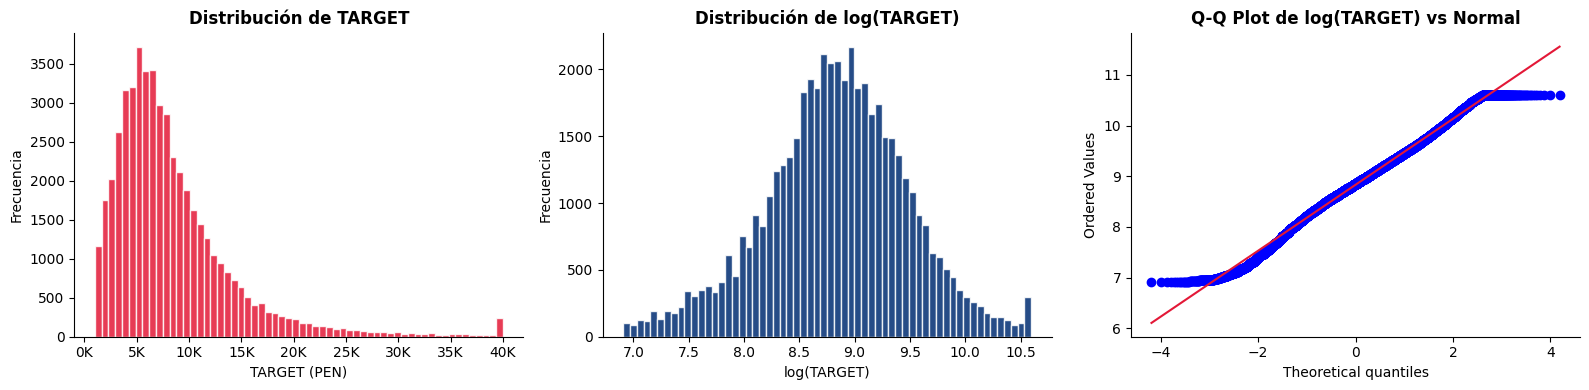

log(TARGET) se aproxima razonablemente a una distribución normal → justifica GLM OLS


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma escala original
axes[0].hist(df['TARGET'], bins=60, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de TARGET', fontsize=12, fontweight='bold')
axes[0].set_xlabel('TARGET (PEN)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Histograma escala log
axes[1].hist(np.log(df['TARGET']), bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución de log(TARGET)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(TARGET)')
axes[1].set_ylabel('Frecuencia')

# Q-Q plot para verificar log-normalidad
stats.probplot(np.log(df['TARGET']), dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de log(TARGET) vs Normal', fontsize=12, fontweight='bold')
axes[2].get_lines()[1].set_color(PALETTE[0])

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('log(TARGET) se aproxima razonablemente a una distribución normal → justifica GLM OLS')

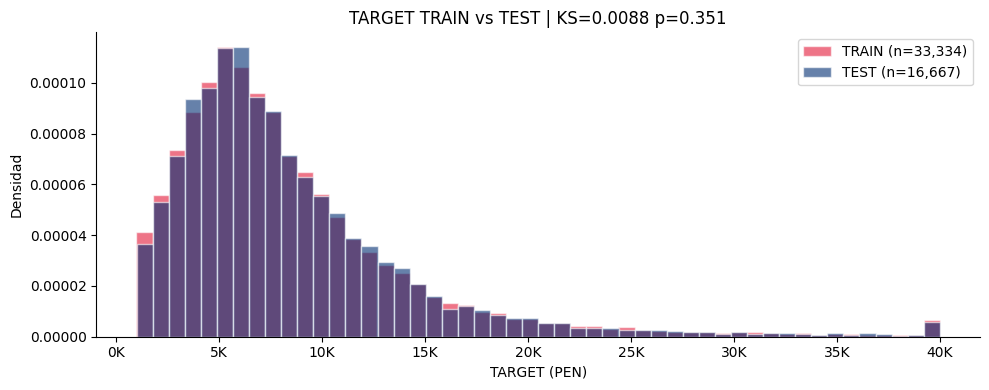

TRAIN y TEST tienen distribuciones estadísticamente similares (KS p > 0.05)


In [7]:
# Comparar distribución de TARGET entre TRAIN y TEST
fig, ax = plt.subplots(figsize=(10, 4))

for grp, color in zip(['TRAIN', 'TEST'], PALETTE[:2]):
    subset = df[df['BASE'] == grp]['TARGET']
    ax.hist(subset, bins=50, alpha=0.6, label=f'{grp} (n={len(subset):,})',
            color=color, density=True, edgecolor='white')

ax.set_title('Distribución de TARGET: TRAIN vs TEST', fontsize=13, fontweight='bold')
ax.set_xlabel('TARGET (PEN)')
ax.set_ylabel('Densidad')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Test Kolmogorov-Smirnov: ¿son idénticas las distribuciones?
ks_stat, ks_pval = stats.ks_2samp(
    df[df['BASE'] == 'TRAIN']['TARGET'],
    df[df['BASE'] == 'TEST']['TARGET']
)
ax.set_title(f'TARGET TRAIN vs TEST | KS={ks_stat:.4f} p={ks_pval:.3f}', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/01_target_train_test.png', dpi=150, bbox_inches='tight')
plt.show()

if ks_pval > 0.05:
    print('TRAIN y TEST tienen distribuciones estadísticamente similares (KS p > 0.05)')
else:
    print('Diferencia estadística en distribución TRAIN vs TEST — verificar partición')

## 4. Calidad de Datos: Missing Values y Valores Centinela

> **Nota importante:** Las variables X3 y X4 usan el valor `-9999998` como código especial
> para indicar ausencia (valor centinela). Este patrón es común en sistemas bancarios core
> donde NULL no puede almacenarse directamente. Se deben convertir a `NaN` antes de cualquier
> análisis o modelado.

In [8]:
# Detectar valores centinela ANTES de reemplazar
sentinel_counts = (df == SENTINEL_VALUE).sum()
print('Valores centinela (-9999998) por columna:')
print(sentinel_counts[sentinel_counts > 0].to_string())

print()

# Reemplazar y luego analizar missing reales
df_clean = replace_sentinels(df)
miss = missing_summary(df_clean)

print('\nResumen de valores faltantes (post-reemplazo de centinelas):')
display(miss)

Valores centinela (-9999998) por columna:
X3    19922
X4    15007


Resumen de valores faltantes (post-reemplazo de centinelas):


,n_missing,pct_missing
X3,19922,39.84
X5,16398,32.80
X4,15007,30.01
X2,4993,9.99
X11,1720,3.44
X12,1720,3.44
X9,912,1.82
X1,786,1.57
X7,551,1.10
X6,1,0.00


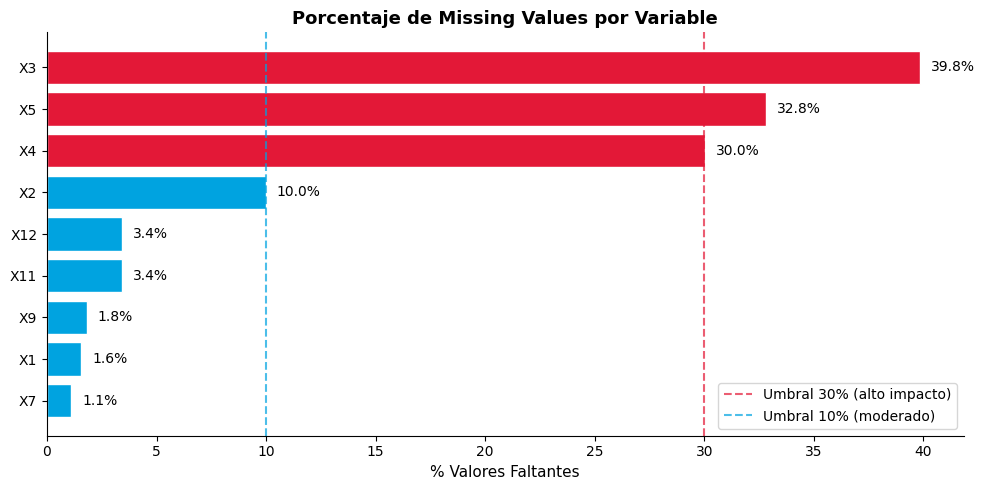

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

miss_to_plot = miss[miss['pct_missing'] > 0].sort_values('pct_missing', ascending=True)
colors = [PALETTE[0] if v > 30 else PALETTE[1] if v > 10 else PALETTE[2]
          for v in miss_to_plot['pct_missing']]

bars = ax.barh(miss_to_plot.index, miss_to_plot['pct_missing'], color=colors, edgecolor='white')

for bar, val in zip(bars, miss_to_plot['pct_missing']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.axvline(30, color=PALETTE[0], linestyle='--', alpha=0.7, label='Umbral 30% (alto impacto)')
ax.axvline(10, color=PALETTE[2], linestyle='--', alpha=0.7, label='Umbral 10% (moderado)')
ax.set_xlabel('% Valores Faltantes', fontsize=11)
ax.set_title('Porcentaje de Missing Values por Variable', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

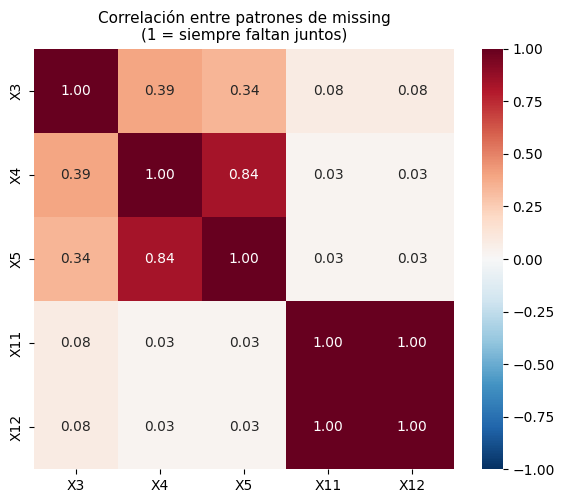

X11 y X12 tienen el mismo patrón de missing en: 100.0% de los casos
→ Probable que X11 y X12 provengan del mismo sistema fuente


In [10]:
# Patrón de co-ocurrencia de missing (¿X11 y X12 siempre faltan juntos?)
missing_mask = df_clean.isnull()

# Correlación entre patrones de ausencia
miss_corr = missing_mask[['X3', 'X4', 'X5', 'X11', 'X12']].astype(int).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(miss_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlación entre patrones de missing\n(1 = siempre faltan juntos)', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_missing_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

x11_x12_together = (missing_mask['X11'] == missing_mask['X12']).mean()
print(f'X11 y X12 tienen el mismo patrón de missing en: {x11_x12_together*100:.1f}% de los casos')
print('→ Probable que X11 y X12 provengan del mismo sistema fuente')

## 5. Distribuciones de Variables Numéricas

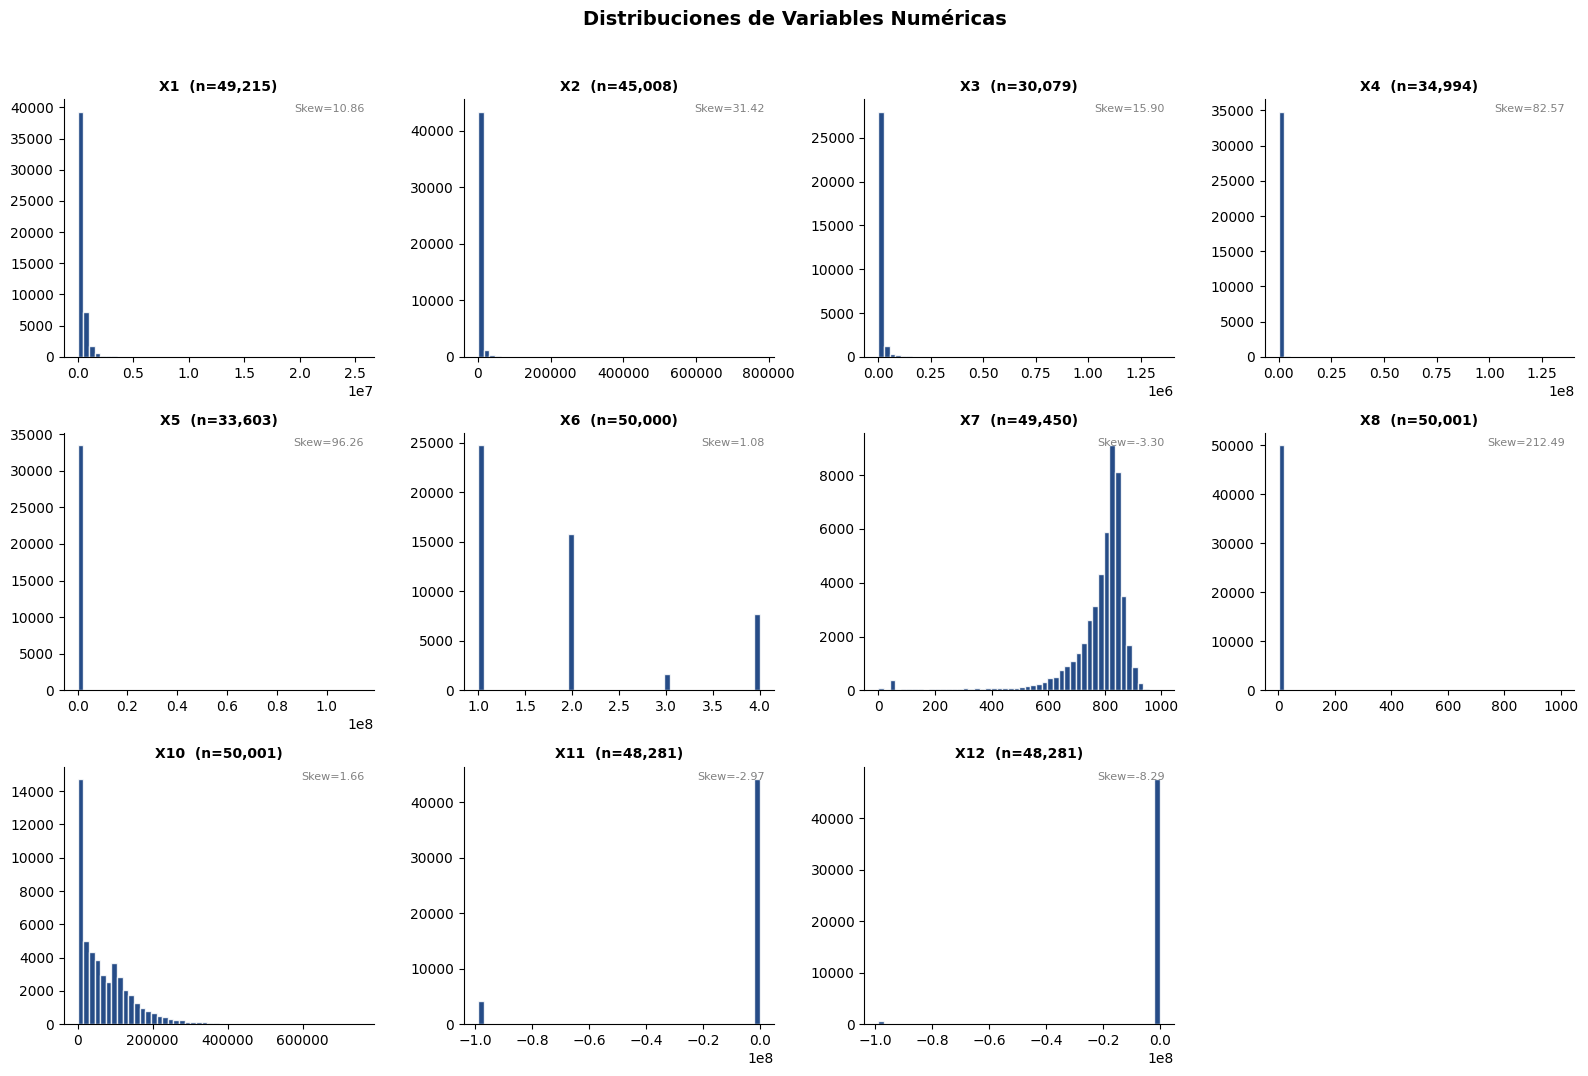

In [11]:
num_cols = NUMERIC_FEATURES
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_clean[col].dropna()
    axes[i].hist(data, bins=50, color=PALETTE[1], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}  (n={len(data):,})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

    # Anotaciones de skewness
    skew = data.skew()
    axes[i].annotate(f'Skew={skew:.2f}', xy=(0.97, 0.95), xycoords='axes fraction',
                     ha='right', fontsize=8, color='gray')

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuciones de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

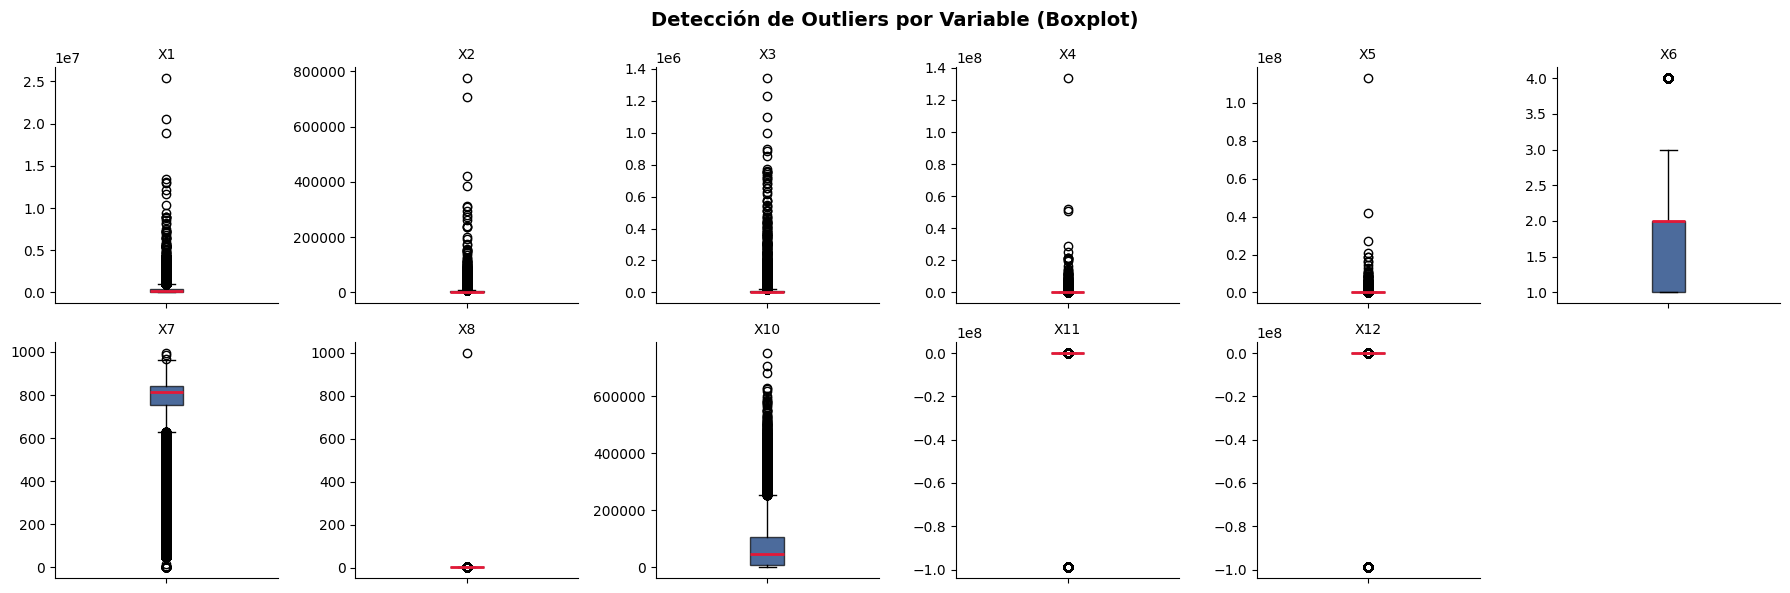

In [12]:
# Análisis de outliers vía boxplot
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_clean[col].dropna()
    bp = axes[i].boxplot(data, patch_artist=True,
                          medianprops={'color': PALETTE[0], 'linewidth': 2})
    bp['boxes'][0].set_facecolor(PALETTE[1])
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Detección de Outliers por Variable (Boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cuantificar outliers extremos (IQR factor=3)
from src.data.preprocessing import detect_outliers_iqr

outlier_summary = []
for col in num_cols:
    data = df_clean[col].dropna()
    mask = detect_outliers_iqr(data, factor=3.0)
    outlier_summary.append({
        'variable': col,
        'n_outliers': mask.sum(),
        'pct_outliers': round(mask.mean() * 100, 2),
        'p1': round(data.quantile(0.01), 1),
        'p99': round(data.quantile(0.99), 1),
        'max': round(data.max(), 1)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

print('\n→ Se usará capping con factor IQR=3 para conservar variabilidad legítima en variables de ingresos/saldos')

,variable,n_outliers,pct_outliers,p1,p99,max
0,X1,1024,2.08,631.0,1979823.9,25398122.0
1,X2,2011,4.47,174.1,30729.5,775572.0
2,X3,1690,5.62,67.0,105055.0,1342785.0
3,X4,1920,5.49,86.9,1486195.5,133648783.0
4,X5,1795,5.34,1.0,1046184.8,113159600.0
5,X6,0,0.00,1.0,4.0,4.0
6,X7,1986,4.02,64.0,911.0,995.0
7,X8,1,0.00,1.0,4.0,999.0
8,X10,176,0.35,0.0,327710.0,751904.0
9,X11,7306,15.13,-99000720.0,1549.4,3600.0



→ Se usará capping con factor IQR=3 para conservar variabilidad legítima en variables de ingresos/saldos


## 6. Variable Categórica X9 — Distrito Geográfico

> X9 contiene nombres de distritos de Perú. La distribución geográfica puede ser un
> predictor relevante del TARGET dado que los ingresos varían significativamente entre
> distritos (ej. San Isidro vs zonas periféricas).

Número total de distritos únicos: 122
Missing en X9: 912 (1.8%)


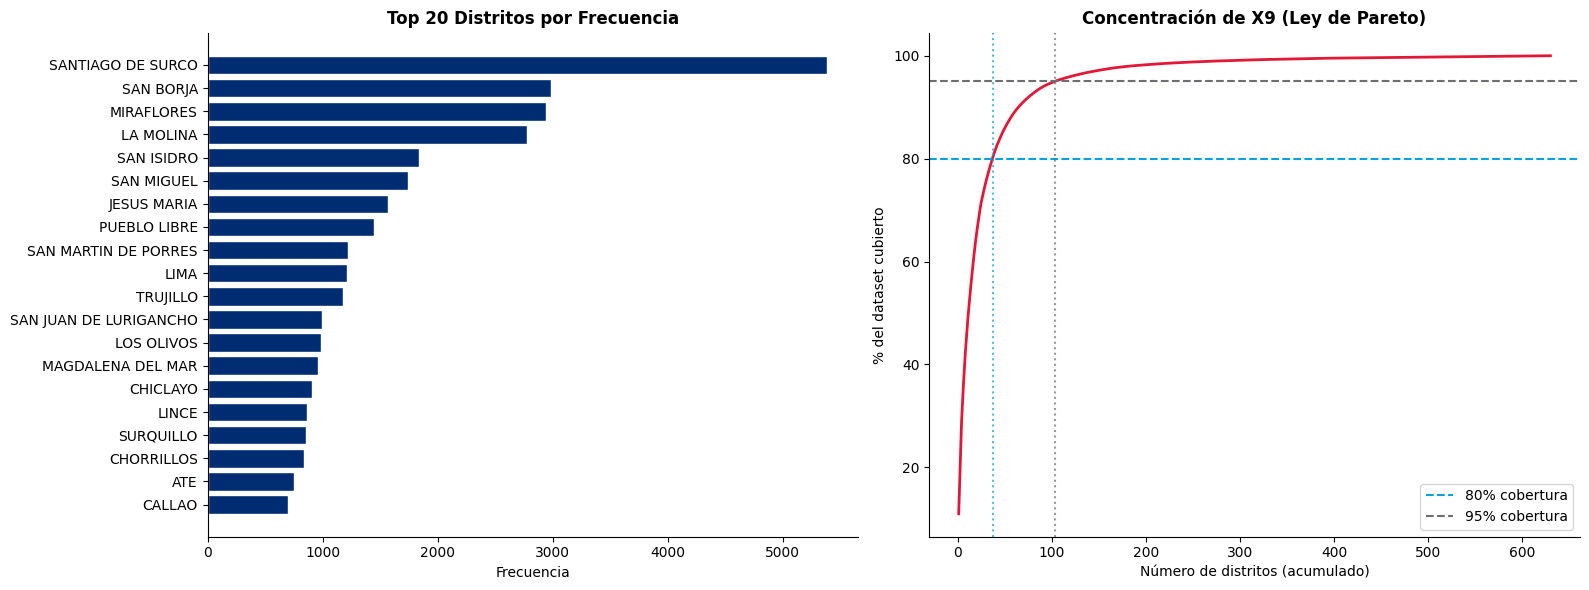


Top 37 distritos cubren el 80% del dataset
Top 103 distritos cubren el 95% del dataset
→ Estrategia de encoding: top-25 distritos como dummies + "OTROS" para el resto


In [14]:
x9_freq = df_clean['X9'].value_counts()
print(f'Número total de distritos únicos: {x9_freq.nunique()}')
print(f'Missing en X9: {df_clean["X9"].isnull().sum():,} ({df_clean["X9"].isnull().mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 distritos por frecuencia
top20 = x9_freq.head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color=PALETTE[1], edgecolor='white')
axes[0].set_title('Top 20 Distritos por Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frecuencia')

# Concentración: % acumulado con top-N distritos
cum_pct = (x9_freq.cumsum() / x9_freq.sum() * 100)
axes[1].plot(range(1, len(cum_pct) + 1), cum_pct.values, color=PALETTE[0], linewidth=2)
axes[1].axhline(80, color=PALETTE[2], linestyle='--', label='80% cobertura')
axes[1].axhline(95, color=PALETTE[3], linestyle='--', label='95% cobertura')
n_for_80 = (cum_pct <= 80).sum() + 1
n_for_95 = (cum_pct <= 95).sum() + 1
axes[1].axvline(n_for_80, color=PALETTE[2], linestyle=':', alpha=0.7)
axes[1].axvline(n_for_95, color=PALETTE[3], linestyle=':', alpha=0.7)
axes[1].set_xlabel('Número de distritos (acumulado)')
axes[1].set_ylabel('% del dataset cubierto')
axes[1].set_title('Concentración de X9 (Ley de Pareto)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/01_x9_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop {n_for_80} distritos cubren el 80% del dataset')
print(f'Top {n_for_95} distritos cubren el 95% del dataset')
print(f'→ Estrategia de encoding: top-25 distritos como dummies + "OTROS" para el resto')

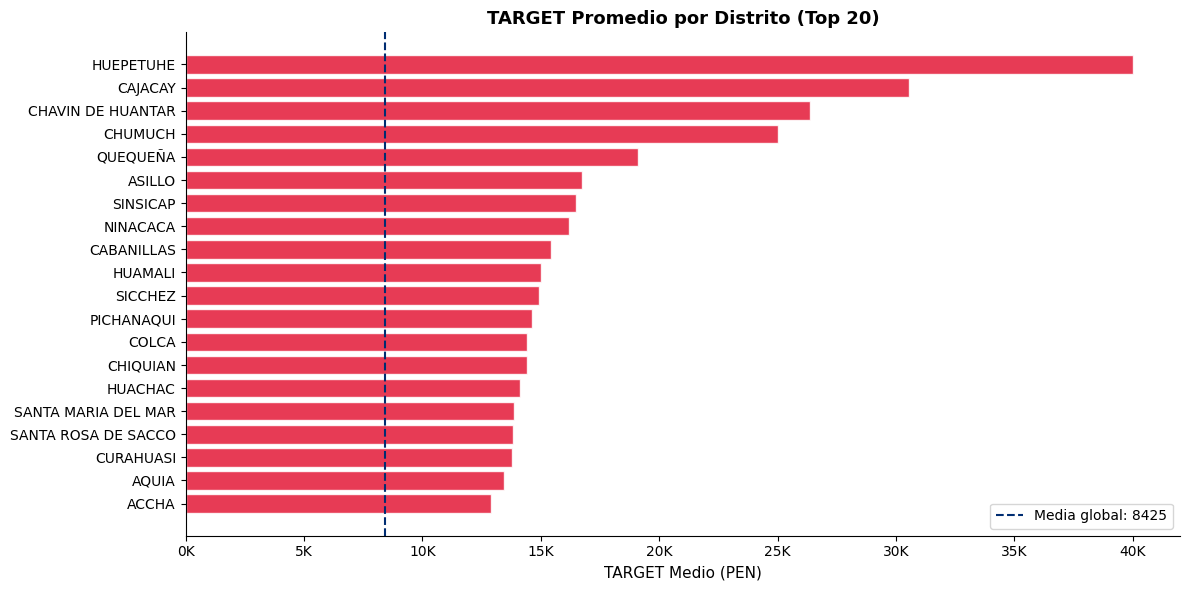

Variabilidad significativa del TARGET entre distritos → X9 es variable relevante


In [15]:
# TARGET medio por distrito (top 20) — clave para validar relevancia predictiva
target_by_district = (
    df_clean.groupby('X9')['TARGET']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(target_by_district.index[::-1], target_by_district['mean'][::-1],
        color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.axvline(df_clean['TARGET'].mean(), color=PALETTE[1], linestyle='--',
           label=f'Media global: {df_clean["TARGET"].mean():.0f}')
ax.set_xlabel('TARGET Medio (PEN)', fontsize=11)
ax.set_title('TARGET Promedio por Distrito (Top 20)', fontsize=13, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../reports/figures/01_target_by_district.png', dpi=150, bbox_inches='tight')
plt.show()

print('Variabilidad significativa del TARGET entre distritos → X9 es variable relevante')

## 7. Análisis de Correlaciones

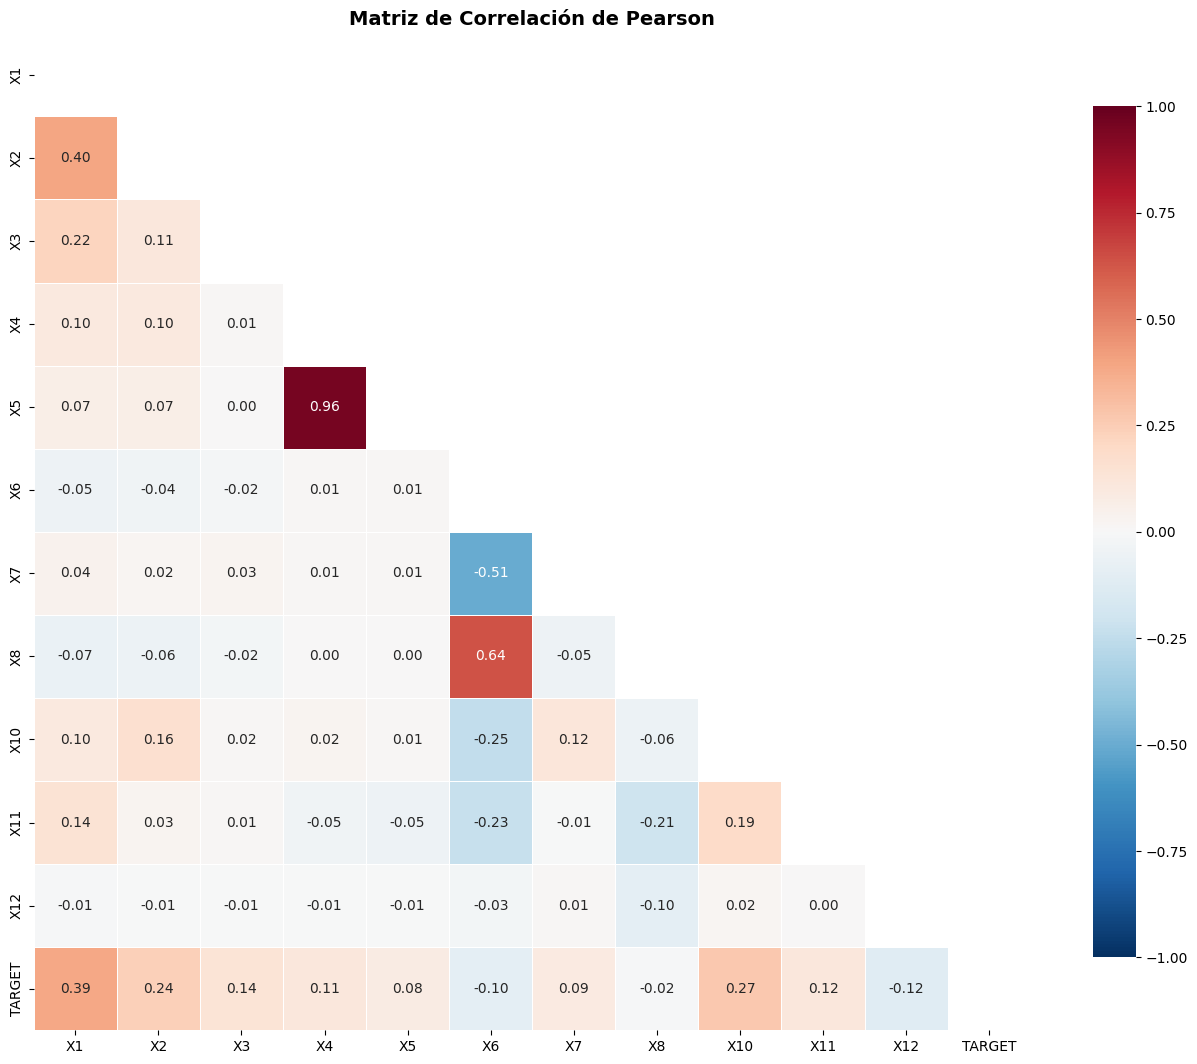


=== Correlación con TARGET (Pearson) ===
X1     0.389737
X10    0.266532
X2     0.235103
X3     0.137307
X12   -0.119354
X11    0.115789
X4     0.111515
X6    -0.101051
X7     0.086941
X5     0.082509
X8    -0.015551


In [16]:
# Matriz de correlación de Pearson en datos limpios
cols_for_corr = num_cols + ['TARGET']
corr_matrix = df_clean[cols_for_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, ax=ax, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlación de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlaciones con TARGET
corr_target = corr_matrix['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)
print('\n=== Correlación con TARGET (Pearson) ===')
print(corr_target.to_string())

## 8. Análisis Bivariado: Features vs TARGET

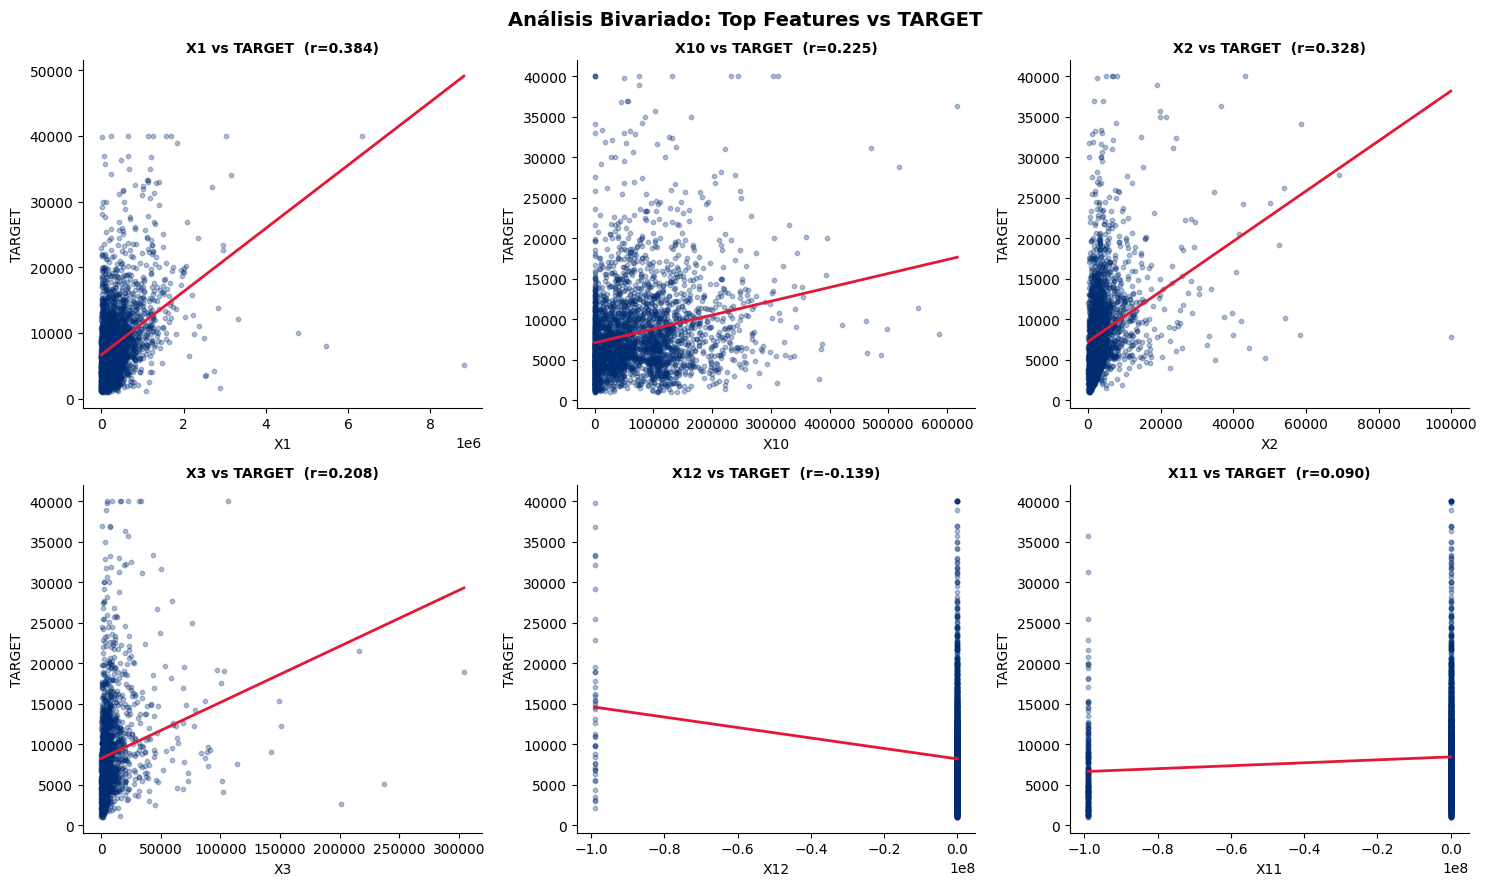

In [17]:
# Scatter plots de las 6 variables con mayor correlación absoluta con TARGET
top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

sample = df_clean.dropna(subset=['TARGET']).sample(min(3000, len(df_clean)), random_state=42)

for i, feat in enumerate(top_features):
    data = sample.dropna(subset=[feat])
    axes[i].scatter(data[feat], data['TARGET'], alpha=0.3, s=10, color=PALETTE[1])

    # Línea de tendencia
    z = np.polyfit(data[feat], data['TARGET'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[feat].min(), data[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color=PALETTE[0], linewidth=2, label='Tendencia')

    corr_val = data[[feat, 'TARGET']].corr().iloc[0, 1]
    axes[i].set_title(f'{feat} vs TARGET  (r={corr_val:.3f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('TARGET')

fig.suptitle('Análisis Bivariado: Top Features vs TARGET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/01_bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Las correlaciones mejoran en espacio log? Verificar para las top features
print('=== Correlación con TARGET vs log(TARGET) ===')
print(f'{"Variable":<8} {"r(TARGET)":>12} {"r(log_TARGET)":>14}')
print('-' * 38)
for feat in top_features:
    data = df_clean[[feat, 'TARGET']].dropna()
    r_orig = data[feat].corr(data['TARGET'])
    r_log = data[feat].corr(np.log(data['TARGET']))
    print(f'{feat:<8} {r_orig:>12.4f} {r_log:>14.4f}')

=== Correlación con TARGET vs log(TARGET) ===
Variable    r(TARGET)  r(log_TARGET)
--------------------------------------
X1             0.3897         0.3404
X10            0.2665         0.2788
X2             0.2351         0.2151
X3             0.1373         0.1335
X12           -0.1194        -0.0976
X11            0.1158         0.1686


## 9. Conclusiones y Decisiones de Preprocesamiento

| Hallazgo | Impacto | Acción |
|----------|---------|--------|
| X3, X4 tienen valores centinela `-9999998` | Contamina estadísticos y modelos | Reemplazar por `NaN` antes de cualquier análisis |
| X3 (40% missing), X4 (30%), X5 (33%) | Alto volumen de ausencias | Imputar por mediana + flag de missingness |
| X11 y X12 siempre co-missing | Provienen del mismo sistema | Tratar como bloque; agregar flag compartido |
| TARGET right-skewed (Skew > 2) | OLS no es adecuado en escala original | Modelar `log(TARGET)` en GLM y LightGBM |
| X9 tiene ~200 categorías | Alta cardinalidad | Top-25 distritos como dummies + OTROS |
| Variables X1, X4, X5 tienen outliers extremos | Pueden distorsionar regresión lineal | Capping con IQR factor=3 |
| Distribución TARGET homogénea TRAIN/TEST | Partición aleatoria válida | Sin ajustes adicionales |

**→ El siguiente paso es `02_preprocessing.ipynb`**